# Olist Delivery Delay Prediction
### Notebook 03: Exploratory Data Analysis (EDA)
---

**Goal:**  
Understand the data deeply before modeling.  
Explore distributions, relationships, and patterns  
that drive late deliveries.

**Input:** `olist_merged.csv` — 96,455 orders × 31 columns  
**Target:** `is_late` — 8.1% late orders

---

### Project Tracks

| Track | Type | Goal |
|-------|------|------|
| Delivery Delay Prediction | Supervised Learning (Binary Classification) | Predict if an order will be late before it ships |
| Customer Segmentation | Unsupervised Learning (Clustering) | Group customers by behavior and experience |

---

### EDA serves both tracks:
- **Classification:** find features correlated with `is_late`
- **Clustering:** understand customer behavior patterns  
  (review score, payment type, order frequency, freight value)

---

### Questions We Want to Answer

**For Classification:**
1. What does the target variable look like? Is there class imbalance?
2. Which features are most associated with late deliveries?
3. Are there geographic patterns in delivery delays?
4. Do product category, price, or weight affect delays?

**For Clustering:**
5. How do customers differ in spending behavior?
6. How does review score relate to delivery experience?
7. Are there patterns in payment method and installments?

---

## Setup

In [5]:
# ── Libraries ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

In [7]:
# ── Load merged dataset from Notebook 02 ──────────────────────
date_cols = ['order_purchase_timestamp',
             'order_approved_at', 
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

df = pd.read_csv('../data/processed/olist_merged.csv',
                 parse_dates=date_cols)

print(f"Shape: {df.shape}")
print(f"\nDate columns dtypes:")
print(df[date_cols].dtypes)

Shape: (96455, 31)

Date columns dtypes:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


---

## Section 1: Univariate Analysis
### 1.1 Target Variable — is_late

Understanding class distribution before any modeling decision.

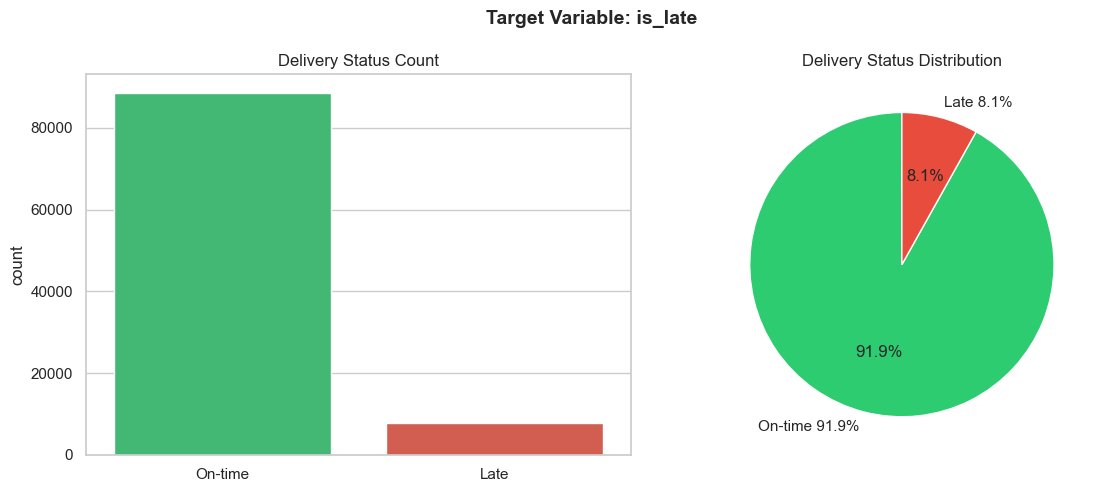

In [9]:
# ── is_late distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='is_late', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Delivery Status Count')
axes[0].set_xticklabels(['On-time', 'Late'])
axes[0].set_xlabel('')

# Pie chart
axes[1].pie([88630, 7825],
            labels=['On-time 91.9%', 'Late 8.1%'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Delivery Status Distribution')

plt.suptitle('Target Variable: is_late', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()